In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/EmotionDataset/punctuation_augmented_isear.xlsx')
df.head()

,Unnamed: 0,content,labels,emotion,clean_content
0,0,on days when i feel close to my partner and ot...,5,joy,day feel close partner friend feel peace also ...
1,1,every time i imagine that someone i love or i ...,4,fear,every time imagine someone love could contact ...
2,2,when i had been obviously unjustly treated and...,0,anger,obviously unjustly treated possibility elucida...
3,3,when i think about the short time that we live...,2,sadness,think short time live relate period life think...
4,4,at a gathering i found myself involuntarily si...,1,disgust,gathering found involuntarily sitting next two...


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical


In [ ]:
vocab_size = 13000
max_length = 60
embedding_dim = 100

epochs = 20
batch_size = 64
random_state = 42

In [ ]:
X = df['clean_content'].astype(str).values
y = df['labels'].values
target_names = sorted(df['emotion'].unique())
num_classes = len(target_names)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=random_state
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=random_state
)

✔ 70% train
✔ 15% validation
✔ 15% test

In [ ]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def tokenize_and_pad(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

X_train_pad = tokenize_and_pad(X_train)
X_val_pad   = tokenize_and_pad(X_val)
X_test_pad  = tokenize_and_pad(X_test)

In [ ]:
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

In [ ]:
model = Sequential([
    Embedding(vocab_size, embedding_dim),

    Bidirectional(
        LSTM(
            64,
            dropout=0.4,
            recurrent_dropout=0.2
        )
    ),

    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 113s 398ms/step - accuracy: 0.1881 - loss: 2.3157 - val_accuracy: 0.4193 - val_loss: 1.5450
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 125s 365ms/step - accuracy: 0.4633 - loss: 1.3930 - val_accuracy: 0.5804 - val_loss: 1.2026
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 91s 369ms/step - accuracy: 0.6026 - loss: 1.0738 - val_accuracy: 0.6357 - val_loss: 1.0416
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 90s 363ms/step - accuracy: 0.7043 - loss: 0.8547 - val_accuracy: 0.6747 - val_loss: 0.9675
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 141s 361ms/step - accuracy: 0.7792 - loss: 0.6998 - val_accuracy: 0.7194 - val_loss: 0.9088
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 143s 366ms/step - accuracy: 0.8321 - loss: 0.5825 - val_accuracy: 0.7416 - val_loss: 0.8689
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 90s 363ms/step - accuracy: 0.8638 - loss: 0.5057 - val_accuracy: 0.7679 - val_loss: 0.8516
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 141s 360ms/step - accuracy: 0.8957 - lo

In [ ]:
y_test_probs = model.predict(X_test_pad)
y_test_pred = np.argmax(y_test_probs, axis=1)

acc = accuracy_score(y_test, y_test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average='macro'
)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step
Test Accuracy : 0.7933
Test Precision: 0.7931
Test Recall   : 0.7932
Test F1-score : 0.7930


In [ ]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=target_names
))

              precision    recall  f1-score   support

       anger       0.78      0.76      0.77       486
     disgust       0.83      0.83      0.83       479
        fear       0.77      0.80      0.78       487
       guilt       0.74      0.72      0.73       482
         joy       0.85      0.84      0.84       485
     sadness       0.82      0.83      0.82       491
       shame       0.76      0.78      0.77       472

    accuracy                           0.79      3382
   macro avg       0.79      0.79      0.79      3382
weighted avg       0.79      0.79      0.79      3382



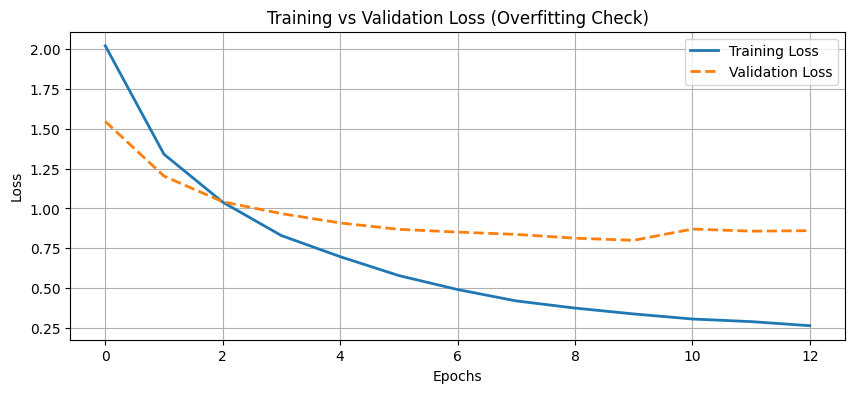

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', lw=2, linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.legend()
plt.grid(True)
plt.show()